# Linear Regression
This is one of the most basic algorithms in ML, that tries to fit a line using the data features to the data observations.

$$\hat y= w_1x_1+w_2x_2+....+w_nx_n+b$$

- w_1..w_n -> weights of each feature of the dataset
- b -> bias term

The model assumes that the independent variables(features) has some kind linear relationship with  each other and errors of prediction at each data point should be independent of each other.\
Also tthe correlation between data should not be very high

To get a line that fits very closely to the data observations, we need to find the w's and b's so that the difference between the prediction and actual values of data is small.

The error metric we want to reduce here is the Mean Squared Error:
$$\frac{1}{n} \sum_{i=1}^{n} (\hat y_i-y_i)^2$$

which allows for penalising higher error heavily


## Gradient Descent for Linear Regression

To find the optimal values of the weight ($w$) and bias ($b$) that best fit a line to the data, we use an optimization algorithm called gradient descent. The purpose of this algorithm is to iteratively adjust the parameters so that the prediction error is minimized.

Take for example linear regression with one variable, whose prediction function is:

$$
\hat{y} = wx + b
$$

To measure how well the model fits the data, we use the Mean Squared Error as the cost function:

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2
$$

- $m$ is the number of training examples  
- $f_{w,b}(x^{(i)}) = wx^{(i)} + b$ is the predicted value  
- $y^{(i)}$ is the actual value  

The factor $\frac{1}{2}$ is included for mathematical convenience, as it simplifies the derivative expressions.

To minimize the cost, we compute the partial derivatives of $J(w, b)$ with respect to $w$ and $b$. These derivatives indicate how the cost changes with small changes in the parameters.

$$
\frac{\partial J(w, b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( (wx^{(i)} + b) - y^{(i)} \right) x^{(i)}
$$

$$
\frac{\partial J(w, b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( (wx^{(i)} + b) - y^{(i)} \right)
$$

The gradient provides both the **direction** and **magnitude** of change required to reduce the cost.

- If the prediction is higher than the actual value, the error is positive, leading to a positive gradient → parameters should be decreased  
- If the prediction is lower than the actual value, the error is negative → parameters should be increased  

The parameters are updated by moving in the opposite direction of the gradient:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

The learning rate $\alpha$ controls the step size, i.e., how much the parameters are updated in the direction of the gradient at each step. Smaller values of $\alpha$ lead to slower convergence towards the minimum loss, while larger values may cause the updates to overshoot the minimum loss or become unstable.

The algorithm starts by initializing $w$ and $b$, and then repeatedly performs the following steps:

- compute predictions using the current parameters  
- measure the cost (error)  
- compute the gradients  
- update the parameters  

This iterative process continues until the change in the cost becomes very small or the parameters stabilize, indicating that the model has reached (or very close to) the minimum.

In [57]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

housedata = fetch_california_housing()
X = housedata.data
y = housedata.target


Mean Squared Error: 0.7091157771765548
R^2 Score: 0.45885918903846656


Text(0, 0.5, 'House Value')

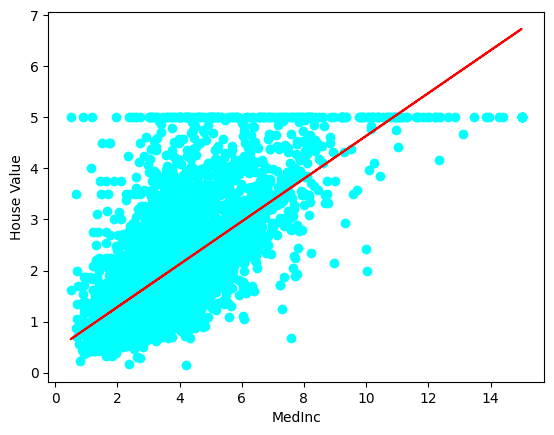

In [58]:
import matplotlib.pyplot as plt

X_tr, X_test, y_tr, y_test = train_test_split(X[:,0].reshape(-1,1), y, test_size=0.2, random_state=42)
LinearReg=LinearRegression()
LinearReg.fit(X_tr, y_tr)
y_pred=LinearReg.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color='cyan', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('MedInc')
plt.ylabel('House Value')

In [62]:
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
LinearReg=LinearRegression()
LinearReg.fit(X_tr, y_tr)
y_pred=LinearReg.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2_score(y_test, y_pred))
residuals = y_test - y_pred


Mean Squared Error: 0.5558915986952425
R^2 Score: 0.5757877060324521
